In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import predict_match
import math as m

file_path = Path('/Users/huangpubo/Desktop/' \
'2025-Summer-Erdos-Elo-Project/Pubo/2025-Summer-Erdos-Elo-Project-6.17/Jimmy/1_Match_Data/matches.csv')

file_name = file_path.stem
#filters the year you want and save to a csv called "elo_v2_1_{from_year}-{to_year}.csv"
df = pd.read_csv(file_path)
from_year = 1997
to_year = 2010

df = df[(df['year'] >= from_year) & (df['year'] <= to_year)]




# Initialize player ratings and game counts, data type=dictionary
player_ratings = {}
player_matches_played = {}
player_matches_won = {}
player_frames_won = {}
player_frames_played = {}

# Set initial rating
initial_rating = 1000


def get_player_rating(player):
    """Get the current rating of the player, initializing if necessary."""
    """这里或许可以加一个逻辑，考虑新选手和老选手的对局得出一个预测分，和1000分来加权平均。
    具体的权重看打的局数"""
    #It is crucial here that we create a new key for each dictionary at the same time so
    #the order of the keys are identical in each dictionary.s
    if player not in player_ratings:
        player_ratings[player] = initial_rating
        player_matches_played[player] = 0
        player_frames_won[player] = 0
        player_frames_played[player] = 0
        player_matches_won[player] = 0
    return player_ratings[player]


def get_K(player):

    return 15
    """Calculate the K value dynamically based on player experience."""
    games_played = player_match_counts[player]
    if games_played < 30:
        return 50
    elif games_played < 100:
        return 30
    else:
        return 20


def margin_of_victory_adjustment(score_diff):
    """Calculate adjustment factor based on margin of victory."""
    return np.log(abs(score_diff) + 1)


def update_ratings(player1, player1_win, player2, player2_win):
    """Update the ratings of player1 and player2 based on the match results."""
    R1 = get_player_rating(player1)
    R2 = get_player_rating(player2)

    # Calculate expected scores
    E1 = 1 / (1 + 2 ** ((R2 - R1) / 100))
    E2 = 1 / (1 + 2 ** ((R1 - R2) / 100))

    # Determine actual scores
    if player1_win == player2_win:  # Handle draw cases
        S1, S2 = 0.5, 0.5
    else:
        S1 = 1 if player1_win > player2_win else 0
        S2 = 1 if player2_win > player1_win else 0

    # Score difference
    score_diff = abs(player1_win - player2_win)

    # Margin of victory adjustment
    MOV = margin_of_victory_adjustment(score_diff)

    # Calculate dynamic K values
    K1 = get_K(player1) * MOV
    K2 = get_K(player2) * MOV


    # Update ratings
    R1_new = R1 + K1 * (S1 - E1)
    R2_new = R2 + K2 * (S2 - E2)


    player_ratings[player1] = R1_new
    player_ratings[player2] = R2_new

    # Increment match counts
    player_matches_played[player1] += 1
    player_matches_played[player2] += 1

    # Increment match win count
    if player1_win > player2_win:
        player_matches_won[player1] +=1
    else:
        player_matches_won[player2] +=1

    # Increment frame won counts
    player_frames_won[player1] += player1_win
    player_frames_won[player2] += player2_win
    player_frames_played[player1] += player1_win + player2_win
    player_frames_played[player2] += player1_win + player2_win

def get_elo(df):
# Process each match in the dataset
    for index, row in df.iterrows():
        player1 = row['player1']
        player1_win = row['score1']
        player2 = row['player2']
        player2_win = row['score2']

        if pd.isnull(player1) or pd.isnull(player2) or pd.isnull(player1_win) or pd.isnull(player2_win):
            continue  # Skip invalid entries

        update_ratings(player1, player1_win, player2, player2_win)
    elo_rating = [round(rating) for rating in list(player_ratings.values())]
    # Create a DataFrame for Elo ratings (Unique Names)
    player_ratings_df = pd.DataFrame({
        'Name': list(player_ratings.keys()),
        'Elo': elo_rating,
        'Frames Won': [player_frames_won[name] for name in player_ratings.keys()],
        'Frames Played': [player_frames_played[name] for name in player_ratings.keys()],
        'Matches Won': [player_matches_won[name] for name in player_matches_won.keys()],
        'Matches Played': [player_matches_played[name] for name in player_ratings.keys()]
    })

    # Print Elo ratings in descending order

    # Save the Elo ratings to a csv file
    player_ratings_df.to_csv(f'/Users/huangpubo/Desktop/2025-Summer-Erdos-Elo-Project/
                             Pubo/elo_v2/elo_v2_1_{from_year}-{to_year}.csv', index=False)
    return player_ratings_df

#get a sorted df
player_ratings_df = get_elo(df).sort_values(by='Elo', ascending=False)
player_ratings_df.head(12)

,Name,Elo,Frames Won,Frames Played,Matches Won,Matches Played
82,Ronnie O'Sullivan,1467,3235,5444,420,580
84,John Higgins,1434,3159,5470,409,602
613,Mark Selby,1409,1835,3311,269,420
139,Stephen Maguire,1408,1905,3356,273,404
902,Mark Allen,1390,1024,1900,155,258
589,Neil Robertson,1388,1506,2756,202,348
607,Marco Fu,1387,1742,3253,245,404
86,Mark Williams,1365,2901,5194,382,602
953,Judd Trump,1364,919,1627,152,237
591,Shaun Murphy,1347,2001,3513,282,430


In [ ]:
#calculate match winrate and frame winrate
matches1982to2025 = pd.read_csv('elo_v2_1_1982-2025.csv')
matches1982to2025['Match Win Rate'] = matches1982to2025['Matches Won'] / matches1982to2025['Matches Played']
matches1982to2025['Frame Win Rate'] = matches1982to2025['Frames Won'] / matches1982to2025['Frames Played']
matches1982to2025 = matches1982to2025.sort_values(by='Elo', ascending=False)
matches1982to2025.head(10)




,Name,Elo,Frames Won,Frames Played,Matches Won,Matches Played,Match Win Rate,Frame Win Rate
1708,Judd Trump,1570,6449,10667,1100,1534,0.717080,0.604575
896,John Higgins,1532,8851,15024,1351,1933,0.698914,0.589124
1416,Mark Selby,1527,6793,11668,1118,1640,0.681707,0.582191
1831,Kyren Wilson,1518,4082,7218,712,1122,0.634581,0.565531
2496,Zhao Xintong,1498,1419,2525,221,375,0.589333,0.561980
840,Ronnie O'Sullivan,1497,8192,13448,1170,1555,0.752412,0.609161
2725,Yan Bingtao,1497,1406,2479,228,354,0.644068,0.567164
1263,Barry Hawkins,1464,5396,9636,869,1391,0.624730,0.559983
1408,Shaun Murphy,1460,5803,10226,917,1413,0.648974,0.567475
1787,Xiao Guodong,1458,2844,5179,475,814,0.583538,0.549141


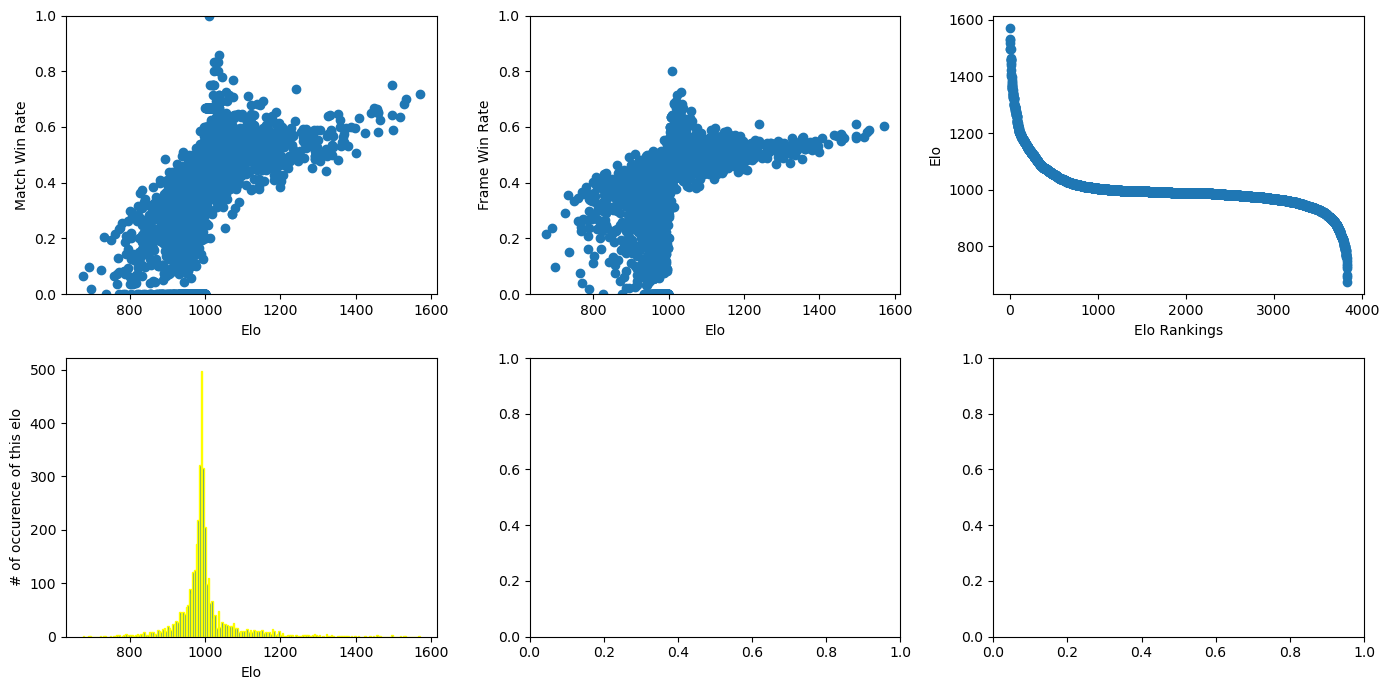

In [ ]:
#plot elo v.s. match winrate
figs, axes = plt.subplots(2,3, figsize=(14,7))
axes[0,0].scatter(matches1982to2025['Elo'], matches1982to2025['Match Win Rate'])
axes[0,0].set_xlabel("Elo")
axes[0,0].set_ylabel("Match Win Rate")
axes[0,0].set_ylim(0,1)
# elo v.s. frame winrate
axes[0,1].scatter(matches1982to2025['Elo'], matches1982to2025['Frame Win Rate'])
axes[0,1].set_xlabel('Elo')
axes[0,1].set_ylabel('Frame Win Rate')
axes[0,1].set_ylim(0,1)
#elo rank versus elo
matches1982to2025['Elo Ranking'] = [i+1 for i in range(0, len(matches1982to2025))]
axes[0,2].scatter(matches1982to2025['Elo Ranking'], matches1982to2025['Elo'])
axes[0,2].set_xlabel('Elo Rankings')
axes[0,2].set_ylabel('Elo')
#distribution of elo ratings
axes[1,0].hist(matches1982to2025['Elo'], bins=200, edgecolor='yellow')
axes[1,0].set_xlabel('Elo')
axes[1,0].set_ylabel('# of occurence of this elo')


plt.tight_layout()
plt.show()


In [24]:
matches_from2000 = pd.read_csv('elo_v2_1_matches_2000-2025.csv')
matches_from2000['Match Win Rate'] = matches_from2000['Matches Won'] / matches_from2000['Matches Played']
matches_from2000['Frame Win Rate'] = matches_from2000['Frames Won'] / matches_from2000['Frames Played']
matches_from2000 = matches_from2000.sort_values(by='Elo', ascending=False)
matches_from2000.head(10)

,Name,Elo,Frames Won,Frames Played,Matches Won,Matches Played,Match Win Rate,Frame Win Rate
609,Judd Trump,1541,6449,10667,1100,1534,0.717080,0.604575
181,John Higgins,1503,6654,11456,1040,1524,0.682415,0.580831
45,Mark Selby,1498,6737,11549,1110,1625,0.683077,0.583341
737,Kyren Wilson,1490,4082,7218,712,1122,0.634581,0.565531
1450,Zhao Xintong,1468,1419,2525,221,375,0.589333,0.561980
178,Ronnie O'Sullivan,1467,5905,9626,846,1119,0.756032,0.613443
1686,Yan Bingtao,1463,1406,2479,228,354,0.644068,0.567164
73,Barry Hawkins,1435,5108,9146,827,1326,0.623680,0.558496
219,Shaun Murphy,1431,5627,9906,890,1371,0.649161,0.568040
691,Xiao Guodong,1429,2844,5179,475,814,0.583538,0.549141


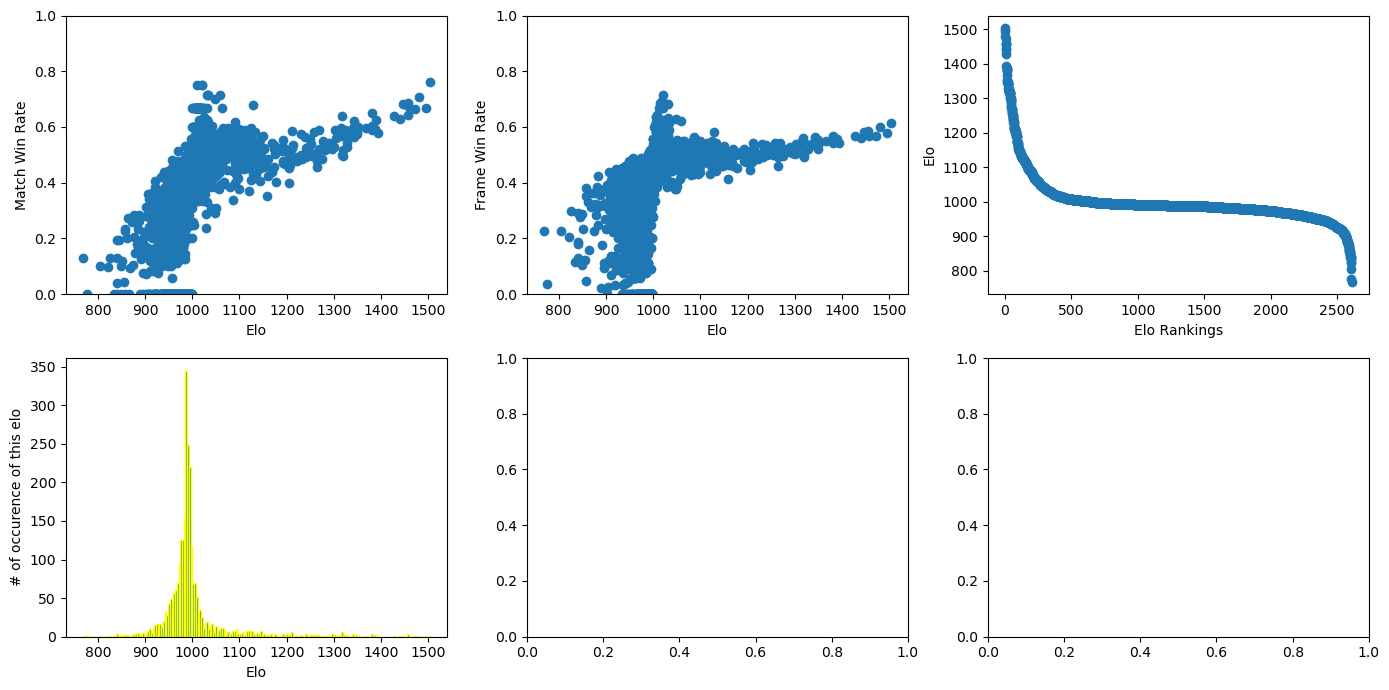

In [36]:
#relation between elo and match win rate could have linear relation
matches2000to2022 = pd.read_csv('elo_v2_1_2000-2022.csv')
matches2000to2022['Match Win Rate'] = matches2000to2022['Matches Won'] / matches2000to2022['Matches Played']
matches2000to2022['Frame Win Rate'] = matches2000to2022['Frames Won'] / matches2000to2022['Frames Played']
matches2000to2022 = matches2000to2022.sort_values(by='Elo', ascending=False)
matches2000to2022.head(10)
figs, axes = plt.subplots(2,3, figsize=(14,7))
axes[0,0].scatter(matches2000to2022['Elo'], matches2000to2022['Match Win Rate'])
axes[0,0].set_xlabel("Elo")
axes[0,0].set_ylabel("Match Win Rate")
axes[0,0].set_ylim(0,1)

axes[0,1].scatter(matches2000to2022['Elo'], matches2000to2022['Frame Win Rate'])
axes[0,1].set_xlabel('Elo')
axes[0,1].set_ylabel('Frame Win Rate')
axes[0,1].set_ylim(0,1)
#elo rank versus elo
matches2000to2022['Elo Ranking'] = [i+1 for i in range(0, len(matches2000to2022))]
axes[0,2].scatter(matches2000to2022['Elo Ranking'], matches2000to2022['Elo'])
axes[0,2].set_xlabel('Elo Rankings')
axes[0,2].set_ylabel('Elo')

axes[1,0].hist(matches2000to2022['Elo'], bins=200, edgecolor='yellow')
axes[1,0].set_xlabel('Elo')
axes[1,0].set_ylabel('# of occurence of this elo')


plt.tight_layout()
plt.show()


In [9]:
matches_to2025_elo_only = matches_to2025[['Name', 'Elo']]
player_ratings_to2025 = dict(zip(matches_to2025['Name'], matches_to2025['Elo']))
predict_match.predict('Kyren Wilson', 'Ding Junhui', player_ratings_to2025, 15)


 Kyren Wilson (1518) v.s. Ding Junhui (1447) in a best of 15.
 Prediction: The winner is Kyren Wilson  with probability 83.3%. Score is 8-5.


(8, 5, 'Kyren Wilson')